# MoRobtrol D 组：收敛曲线、最终前沿与时间质量表

先运行 `tests/benchmark/MoRobtrol/analyze_quality.py` 生成 `results/data/*.csv`。本 notebook 只负责读取派生数据和 `checkpoint_rewards.pt` 做可视化展示，不重新优化、不重新独立评估、不保存图片/PDF。

In [1]:
from pathlib import Path
import json
import os

os.environ.setdefault('MPLCONFIGDIR', '/tmp/matplotlib-cuda-moea')

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from IPython.display import display

repo_root = Path.cwd().resolve()
while not (repo_root / 'tests' / 'benchmark').exists():
    if repo_root.parent == repo_root:
        raise RuntimeError('请从 CUDA-MOEA 仓库内启动 notebook')
    repo_root = repo_root.parent

# 如本轮数据目录不同，修改这里即可。
runs_root = repo_root / 'output/benchmark_20260711'
results_root = repo_root / 'tests/benchmark/MoRobtrol/results'
data_root = results_root / 'data'

checkpoint_metrics = pd.read_csv(data_root / 'checkpoint_metrics.csv')
quality_at_time = pd.read_csv(data_root / 'quality_at_time.csv')
time_to_target = pd.read_csv(data_root / 'time_to_target.csv')

print('repo_root =', repo_root)
print('runs_root =', runs_root)
print('checkpoint_metrics:', checkpoint_metrics.shape)
print('quality_at_time:', quality_at_time.shape)
print('time_to_target:', time_to_target.shape)

if 'common_horizon_ms' not in quality_at_time.columns:
    print('WARNING: quality_at_time.csv 缺少 common_horizon_ms；请重新运行 analyze_quality.py，旧表可能包含超出共同观测时间范围的预算。')
if 'target_scope' not in time_to_target.columns:
    print('WARNING: time_to_target.csv 缺少 target_scope；请重新运行 analyze_quality.py 以获得更明确的目标解释字段。')


repo_root = <repo>
runs_root = <repo>/output/benchmark_20260711
checkpoint_metrics: (1680, 12)
quality_at_time: (44, 17)
time_to_target: (32, 15)


In [2]:
ENVIRONMENT_ORDER = [
    'mo_halfcheetah', 'mo_hopper_m3', 'mo_humanoid',
    'mo_humanoidstandup', 'mo_inverted_double_pendulum',
    'mo_pusher', 'mo_reacher', 'mo_swimmer', 'mo_walker2d',
]

IMPLEMENTATION_ORDER = [
    ('cuda_moea', 'nsga3'),
    ('evox', 'nsga3'),
    ('cuda_moea', 'rvea'),
    ('evox', 'rvea'),
]

LABELS = {
    ('cuda_moea', 'nsga3'): 'CUDA-MOEA–NSGA-III',
    ('evox', 'nsga3'): 'EvoX–NSGA-III',
    ('cuda_moea', 'rvea'): 'CUDA-MOEA–RVEA',
    ('evox', 'rvea'): 'EvoX–RVEA',
}

STYLES = {
    ('cuda_moea', 'nsga3'): dict(color='#8CAFCF', marker='o', linestyle='-'),
    ('evox', 'nsga3'): dict(color='#EA8675', marker='o', linestyle='-'),
    ('cuda_moea', 'rvea'): dict(color='#BDB8D9', marker='s', linestyle='--'),
    ('evox', 'rvea'): dict(color='#F5C184', marker='s', linestyle='--'),
}

METRIC_LABELS = {'hv': 'Hypervolume', 'eu': 'Expected utility'}

pd.set_option('display.max_columns', 40)
pd.set_option('display.max_rows', 120)
pd.set_option('display.float_format', lambda value: f'{value:.4g}')

plt.rcParams.update({
    'figure.dpi': 130,
    'font.size': 11,
    'axes.labelsize': 12,
    'axes.titlesize': 11,
    'legend.fontsize': 9,
    'axes.linewidth': 0.8,
    'xtick.direction': 'out',
    'ytick.direction': 'out',
})

In [3]:
def available_environments(data=checkpoint_metrics):
    return [env for env in ENVIRONMENT_ORDER if env in set(data['environment'])]


def summarize_metric(data, *, x_kind, metric, environment, framework, algorithm):
    selected = data[
        (data['environment'] == environment)
        & (data['framework'] == framework)
        & (data['algorithm'] == algorithm)
    ]
    rows = []
    for generation, group in selected.groupby('generation', sort=True):
        x_values = (
            np.full(len(group), generation, dtype=float)
            if x_kind == 'generation'
            else group['checkpoint_cumulative_time_ms'].to_numpy(dtype=float) / 60000.0
        )
        y_values = group[metric].to_numpy(dtype=float)
        q1, median, q3 = np.quantile(y_values, [0.25, 0.5, 0.75])
        rows.append((float(np.median(x_values)), float(q1), float(median), float(q3)))
    return np.asarray(rows, dtype=float)


def style_axes(axis):
    axis.grid(True, linestyle='--', linewidth=0.55, alpha=0.45)
    axis.set_axisbelow(True)
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)


def plot_environment_curves(environment, *, x_kind='generation', data=checkpoint_metrics):
    fig, axes = plt.subplots(1, 2, figsize=(12.0, 4.4), sharex=False)
    for metric, axis in zip(('hv', 'eu'), axes):
        for framework, algorithm in IMPLEMENTATION_ORDER:
            summary = summarize_metric(
                data, x_kind=x_kind, metric=metric, environment=environment,
                framework=framework, algorithm=algorithm,
            )
            if summary.size == 0:
                continue
            x, q1, median, q3 = summary.T
            style = STYLES[(framework, algorithm)]
            axis.fill_between(x, q1, q3, color=style['color'], alpha=0.36, linewidth=0)
            axis.plot(
                x, median, color=style['color'], marker=style['marker'],
                linestyle=style['linestyle'], linewidth=1.15, markersize=4,
                label=LABELS[(framework, algorithm)],
            )
        axis.set_xlabel('Generation' if x_kind == 'generation' else 'Algorithm time (min)')
        axis.set_ylabel(METRIC_LABELS[metric])
        if x_kind == 'generation':
            generations = sorted(data[data['environment'] == environment]['generation'].unique())
            axis.set_xticks(generations[::2] if len(generations) > 12 else generations)
        style_axes(axis)
    axes[0].legend(frameon=False, ncol=1)
    fig.suptitle(environment, y=1.02, fontsize=12)
    fig.tight_layout()
    plt.show()


def plot_all_environment_curves(*, x_kind='generation', data=checkpoint_metrics):
    for environment in available_environments(data):
        plot_environment_curves(environment, x_kind=x_kind, data=data)

## Generation–HV/EU

每个环境一张图，左侧 HV、右侧 EU；线为 10 个 seed 的中位数，阴影为 IQR。

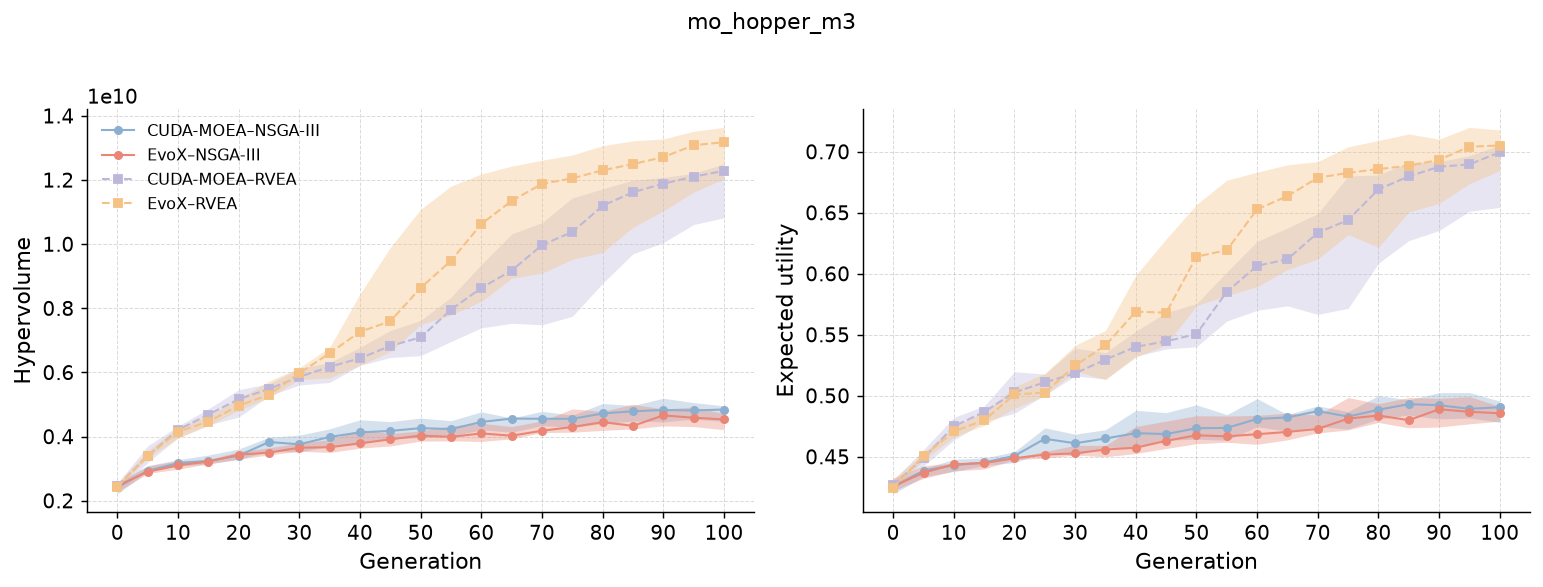

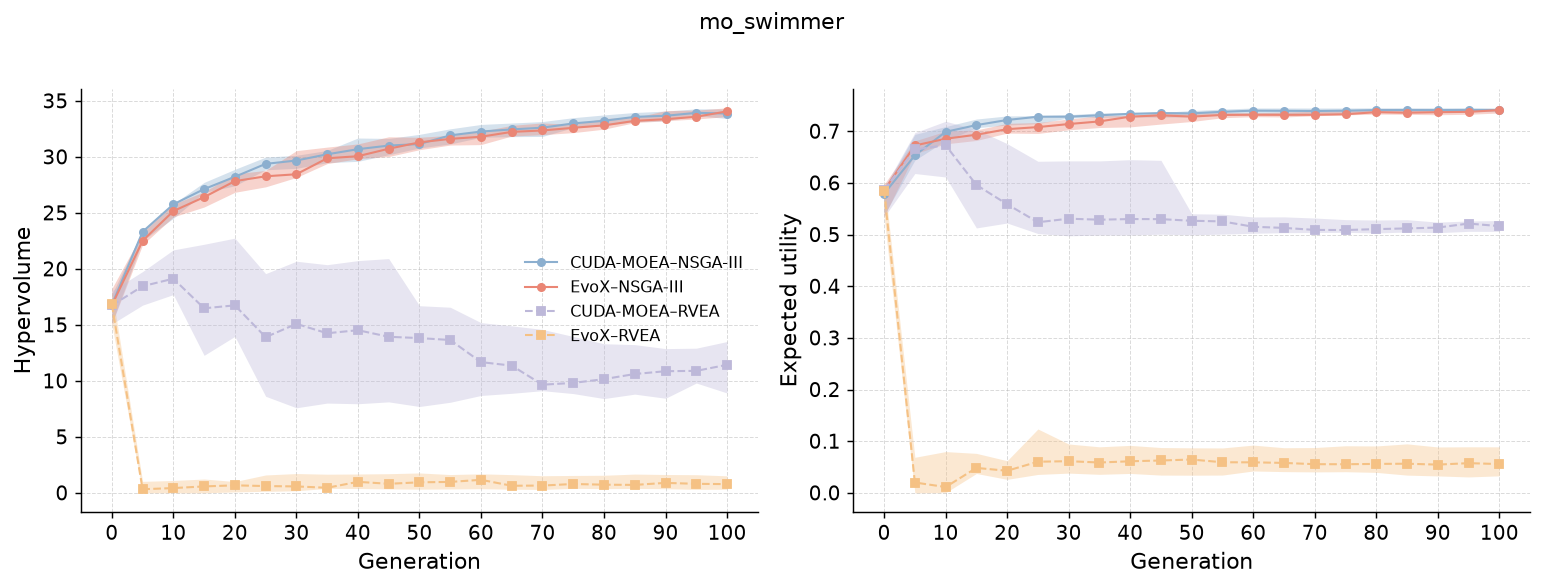

In [4]:
plot_all_environment_curves(x_kind='generation')

## Time–HV/EU

横轴为 D 组记录的检查点累计**算法时间**，单位 min；不包含独立评估、指标计算、写盘和绘图。

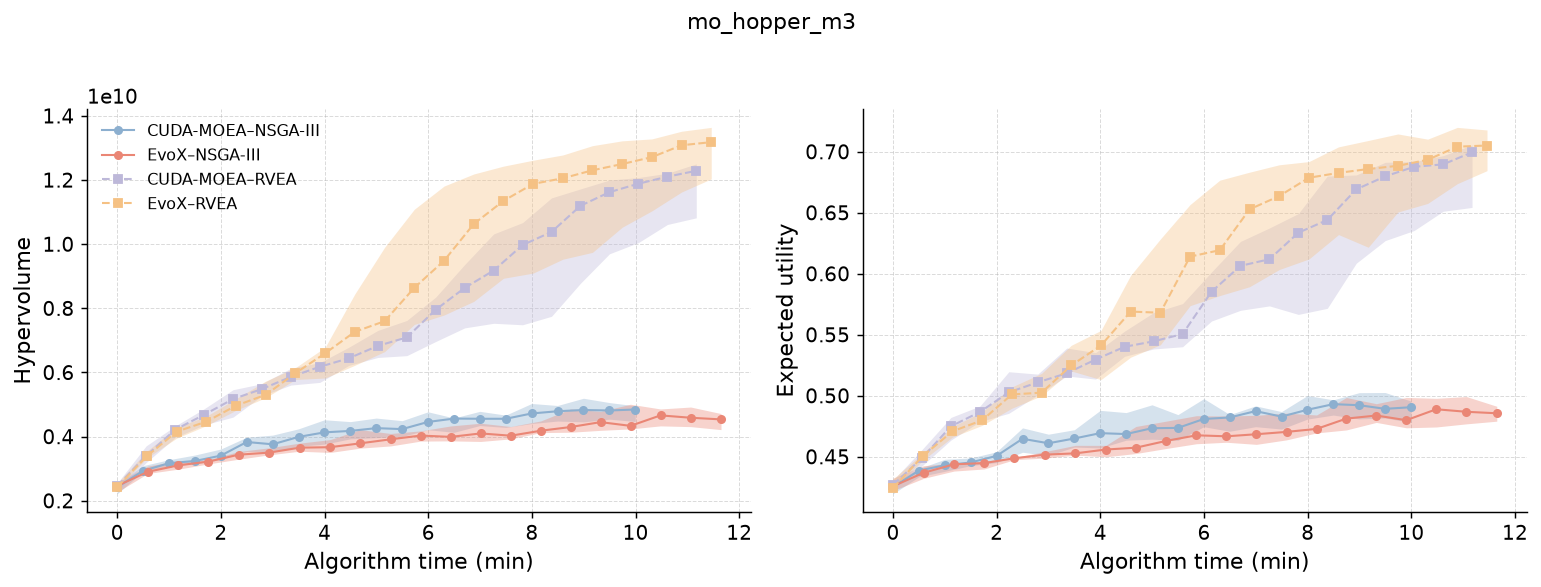

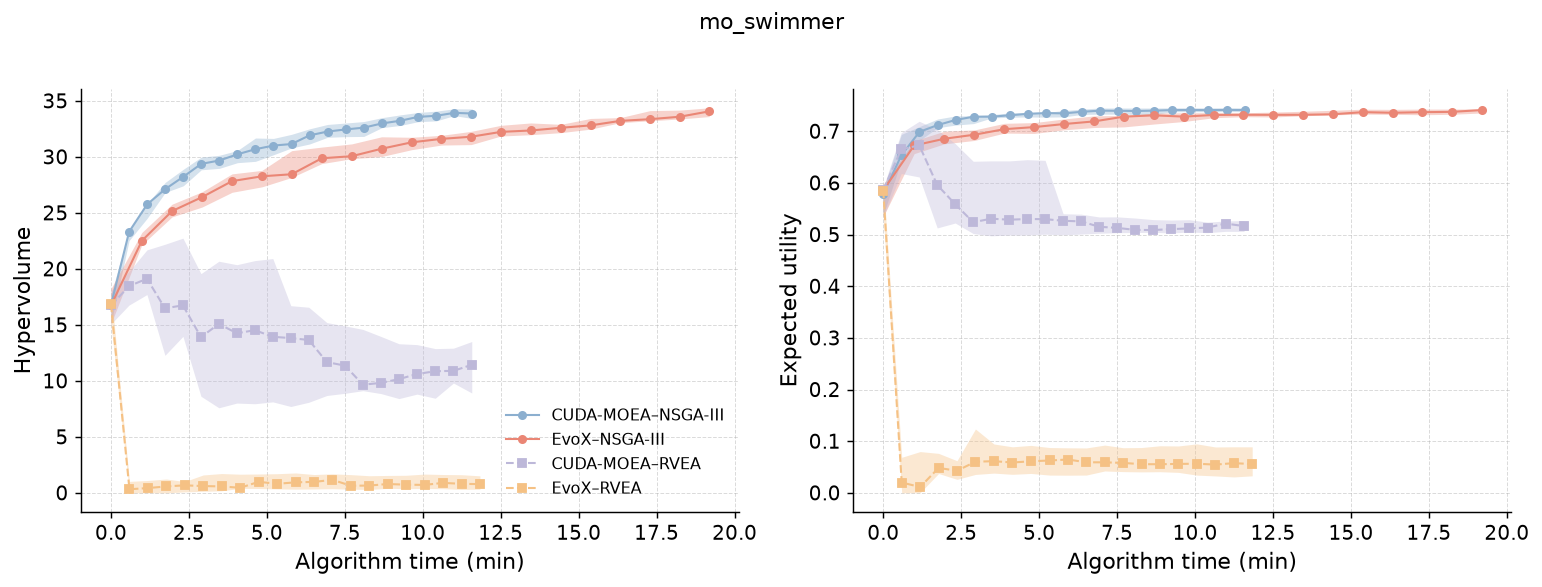

In [5]:
plot_all_environment_curves(x_kind='time')

## Quality-at-time 表

HV 和 EU 分开显示；同一行对比 CUDA-MOEA 与 EvoX，便于查看相同算法、相同时间预算下的质量差异。

In [6]:
def format_number(value, digits=4):
    if pd.isna(value):
        return '—'
    return f'{float(value):.{digits}g}'


def format_interval(median, q1, q3, digits=4):
    return f'{format_number(median, digits)} [{format_number(q1, digits)}, {format_number(q3, digits)}]'


def quality_at_time_view(metric):
    df = quality_at_time[quality_at_time['metric'] == metric].copy()
    df['budget_time_min'] = df['budget_time_ms'] / 60000.0
    if 'common_horizon_ms' in df.columns:
        df['common_horizon_min'] = df['common_horizon_ms'] / 60000.0
    value_columns = ['median', 'q1', 'q3', 'missing']
    index_columns = ['environment', 'algorithm', 'budget_source', 'budget_time_min']
    if 'common_horizon_min' in df.columns:
        index_columns.append('common_horizon_min')
    wide = df.pivot_table(
        index=index_columns,
        columns='framework', values=value_columns, aggfunc='first',
    )
    wide.columns = [f'{framework}_{value}' for value, framework in wide.columns]
    wide = wide.reset_index()

    for framework in ('cuda_moea', 'evox'):
        needed = {f'{framework}_median', f'{framework}_q1', f'{framework}_q3'}
        if needed <= set(wide.columns):
            wide[f'{framework}_quality'] = wide.apply(
                lambda row: format_interval(
                    row[f'{framework}_median'], row[f'{framework}_q1'], row[f'{framework}_q3']
                ),
                axis=1,
            )
    if {'cuda_moea_median', 'evox_median'} <= set(wide.columns):
        wide['CUDA_minus_EvoX_median'] = wide['cuda_moea_median'] - wide['evox_median']
        wide['CUDA_minus_EvoX_median'] = wide['CUDA_minus_EvoX_median'].map(format_number)

    wide['budget_time_min'] = wide['budget_time_min'].map(lambda value: format_number(value, 5))
    if 'common_horizon_min' in wide.columns:
        wide['common_horizon_min'] = wide['common_horizon_min'].map(lambda value: format_number(value, 5))
    ordered = [
        'environment', 'algorithm', 'budget_source', 'budget_time_min', 'common_horizon_min',
        'cuda_moea_quality', 'cuda_moea_missing',
        'evox_quality', 'evox_missing', 'CUDA_minus_EvoX_median',
    ]
    ordered = [col for col in ordered if col in wide.columns]
    table = wide[ordered].sort_values(['environment', 'algorithm', 'budget_source'])
    table = table.rename(columns={
        'budget_time_min': 'budget_time_min',
        'cuda_moea_quality': 'CUDA-MOEA median [q1, q3]',
        'cuda_moea_missing': 'CUDA-MOEA missing',
        'evox_quality': 'EvoX median [q1, q3]',
        'evox_missing': 'EvoX missing',
        'CUDA_minus_EvoX_median': 'CUDA-MOEA−EvoX median',
    })
    return table


print('Quality-at-time: HV')
display(quality_at_time_view('hv'))
print('Quality-at-time: EU')
display(quality_at_time_view('eu'))


Quality-at-time: HV


,environment,algorithm,budget_source,budget_time_min,common_horizon_min,"CUDA-MOEA median [q1, q3]",CUDA-MOEA missing,"EvoX median [q1, q3]",EvoX missing,CUDA-MOEA−EvoX median
0,mo_hopper_m3,nsga3,EvoX generation 25 median,2.9305,9.9926,"3.833e+09 [3.538e+09, 3.981e+09]",0,"3.502e+09 [3.375e+09, 3.559e+09]",0,3.31e+08
1,mo_hopper_m3,nsga3,EvoX generation 50 median,5.8543,9.9926,"4.235e+09 [4.005e+09, 4.498e+09]",0,"3.945e+09 [3.783e+09, 4.101e+09]",0,2.901e+08
2,mo_hopper_m3,nsga3,EvoX generation 75 median,8.7459,9.9926,"4.791e+09 [4.486e+09, 4.971e+09]",0,"4.228e+09 [4.148e+09, 4.499e+09]",0,5.632e+08
3,mo_hopper_m3,rvea,EvoX generation 25 median,2.8655,11.17,"5.486e+09 [5.275e+09, 5.651e+09]",0,"5.192e+09 [5.056e+09, 5.375e+09]",0,2.941e+08
4,mo_hopper_m3,rvea,EvoX generation 50 median,5.7305,11.17,"7.096e+09 [6.525e+09, 7.622e+09]",0,"8.053e+09 [6.803e+09, 1.109e+10]",0,-9.57e+08
5,mo_hopper_m3,rvea,EvoX generation 75 median,8.5949,11.17,"1.038e+10 [7.752e+09, 1.144e+10]",0,"1.191e+10 [9.251e+09, 1.278e+10]",0,-1.53e+09
6,mo_swimmer,nsga3,EvoX generation 25 median,4.841,11.59,"30.68 [29.6, 31.68]",0,"27.86 [26.84, 28.72]",0,2.825
7,mo_swimmer,nsga3,EvoX generation 50 median,9.6404,11.59,"33.22 [32.8, 33.74]",0,"30.84 [30.14, 31.53]",0,2.376
8,mo_swimmer,rvea,EvoX generation 25 median,2.9565,11.571,"14.08 [8.554, 19.57]",0,"0.5286 [0.08181, 1.681]",0,13.55
9,mo_swimmer,rvea,EvoX generation 50 median,5.9237,11.571,"13.82 [7.707, 16.71]",0,"0.8055 [0.3276, 1.731]",0,13.01


Quality-at-time: EU


,environment,algorithm,budget_source,budget_time_min,common_horizon_min,"CUDA-MOEA median [q1, q3]",CUDA-MOEA missing,"EvoX median [q1, q3]",EvoX missing,CUDA-MOEA−EvoX median
0,mo_hopper_m3,nsga3,EvoX generation 25 median,2.9305,9.9926,"0.4647 [0.4537, 0.4737]",0,"0.4495 [0.448, 0.4523]",0,0.01526
1,mo_hopper_m3,nsga3,EvoX generation 50 median,5.8543,9.9926,"0.4736 [0.4635, 0.4845]",0,"0.4645 [0.4588, 0.4792]",0,0.009148
2,mo_hopper_m3,nsga3,EvoX generation 75 median,8.7459,9.9926,"0.4931 [0.4842, 0.4966]",0,"0.4752 [0.4717, 0.4842]",0,0.01795
3,mo_hopper_m3,rvea,EvoX generation 25 median,2.8655,11.17,"0.511 [0.5006, 0.5177]",0,"0.5011 [0.4988, 0.5099]",0,0.009927
4,mo_hopper_m3,rvea,EvoX generation 50 median,5.7305,11.17,"0.5506 [0.5402, 0.5755]",0,"0.5893 [0.5511, 0.6567]",0,-0.03868
5,mo_hopper_m3,rvea,EvoX generation 75 median,8.5949,11.17,"0.6441 [0.5716, 0.6801]",0,"0.6787 [0.6161, 0.704]",0,-0.03462
6,mo_swimmer,nsga3,EvoX generation 25 median,4.841,11.59,"0.7337 [0.7276, 0.7359]",0,"0.7038 [0.6963, 0.7148]",0,0.02991
7,mo_swimmer,nsga3,EvoX generation 50 median,9.6404,11.59,"0.7409 [0.7377, 0.7453]",0,"0.7283 [0.7157, 0.7353]",0,0.01263
8,mo_swimmer,rvea,EvoX generation 25 median,2.9565,11.571,"0.5228 [0.4989, 0.6418]",0,"0.05561 [0.03557, 0.118]",0,0.4672
9,mo_swimmer,rvea,EvoX generation 50 median,5.9237,11.571,"0.5266 [0.4994, 0.5402]",0,"0.06314 [0.03408, 0.08756]",0,0.4635


## Time-to-target 表

HV 和 EU 分开显示；同一行对比 CUDA-MOEA 与 EvoX 的达到率和达到目标的累计时间。加速比以时间中位数计算，`EvoX / CUDA-MOEA` 大于 1 表示 CUDA-MOEA 更快。`NaN` 表示没有 seed 达到该目标。

In [7]:
def format_rate(reached_rate, reached, total, digits=4):
    if pd.isna(reached_rate):
        return '—'
    return f'{float(reached_rate):.{digits}g} [{int(reached)}/{int(total)}]'


def time_to_target_view(metric):
    df = time_to_target[time_to_target['metric'] == metric].copy()
    for col in ['time_ms_median', 'time_ms_q1', 'time_ms_q3']:
        df[col.replace('ms', 'min')] = df[col] / 60000.0
    value_columns = [
        'target_value', 'reached', 'total', 'reached_rate',
        'time_min_median', 'time_min_q1', 'time_min_q3',
    ]
    index_columns = ['environment', 'algorithm', 'target_label']
    if 'target_scope' in df.columns:
        index_columns.append('target_scope')
    wide = df.pivot_table(
        index=index_columns,
        columns='framework', values=value_columns, aggfunc='first',
    )
    wide.columns = [f'{framework}_{value}' for value, framework in wide.columns]
    wide = wide.reset_index()

    for framework in ('cuda_moea', 'evox'):
        rate_columns = {f'{framework}_reached_rate', f'{framework}_reached', f'{framework}_total'}
        time_columns = {f'{framework}_time_min_median', f'{framework}_time_min_q1', f'{framework}_time_min_q3'}
        if rate_columns <= set(wide.columns):
            wide[f'{framework}_reached_summary'] = wide.apply(
                lambda row: format_rate(
                    row[f'{framework}_reached_rate'], row[f'{framework}_reached'], row[f'{framework}_total']
                ),
                axis=1,
            )
        if time_columns <= set(wide.columns):
            wide[f'{framework}_time_summary_min'] = wide.apply(
                lambda row: format_interval(
                    row[f'{framework}_time_min_median'],
                    row[f'{framework}_time_min_q1'],
                    row[f'{framework}_time_min_q3'],
                    digits=4,
                ),
                axis=1,
            )

    speedup_columns = {'cuda_moea_time_min_median', 'evox_time_min_median'}
    if speedup_columns <= set(wide.columns):
        def format_speedup(row):
            cuda_time = row['cuda_moea_time_min_median']
            evox_time = row['evox_time_min_median']
            if pd.isna(cuda_time) or pd.isna(evox_time):
                return '—'
            if cuda_time == 0:
                return '1×' if evox_time == 0 else '∞×'
            return f'{evox_time / cuda_time:.4g}×'

        wide['speedup'] = wide.apply(format_speedup, axis=1)

    if 'evox_target_value' in wide.columns:
        wide['target_value'] = wide['evox_target_value'].map(format_number)
    elif 'cuda_moea_target_value' in wide.columns:
        wide['target_value'] = wide['cuda_moea_target_value'].map(format_number)

    ordered = [
        'environment', 'algorithm', 'target_label', 'target_scope', 'target_value',
        'cuda_moea_reached_summary', 'cuda_moea_time_summary_min',
        'evox_reached_summary', 'evox_time_summary_min', 'speedup',
    ]
    ordered = [col for col in ordered if col in wide.columns]
    table = wide[ordered].sort_values(['environment', 'algorithm', 'target_label'])
    table = table.rename(columns={
        'cuda_moea_reached_summary': 'CUDA-MOEA reached_rate [reached/total]',
        'cuda_moea_time_summary_min': 'CUDA-MOEA time min median [q1, q3]',
        'evox_reached_summary': 'EvoX reached_rate [reached/total]',
        'evox_time_summary_min': 'EvoX time min median [q1, q3]',
        'speedup': 'Speedup（EvoX / CUDA-MOEA）',
    })
    return table


print('Time-to-target: HV')
display(time_to_target_view('hv'))
print('Time-to-target: EU')
display(time_to_target_view('eu'))


Time-to-target: HV


,environment,algorithm,target_label,target_scope,target_value,CUDA-MOEA reached_rate [reached/total],"CUDA-MOEA time min median [q1, q3]",EvoX reached_rate [reached/total],"EvoX time min median [q1, q3]",Speedup（EvoX / CUDA-MOEA）
0,mo_hopper_m3,nsga3,90% EvoX final median,within observed 100-generation run,4.084e+09,1 [10/10],"3.997 [2.624, 4.999]",1 [10/10],"6.983 [5.182, 8.167]",1.747×
1,mo_hopper_m3,nsga3,EvoX final median,within observed 100-generation run,4.538e+09,0.9 [9/10],"5.501 [4, 6.492]",0.7 [7/10],"8.752 [7.072, 9.885]",1.591×
2,mo_hopper_m3,rvea,90% EvoX final median,within observed 100-generation run,1.186e+10,0.6 [6/10],"9.496 [9.074, 9.913]",0.7 [7/10],"7.441 [6.294, 8.038]",0.7836×
3,mo_hopper_m3,rvea,EvoX final median,within observed 100-generation run,1.318e+10,0 [0/10],"— [—, —]",0.5 [5/10],"9.151 [8.583, 9.746]",—
4,mo_swimmer,nsga3,90% EvoX final median,within observed 100-generation run,30.65,1 [10/10],"5 [4.206, 5.769]",1 [10/10],"9.217 [6.061, 10.33]",1.844×
5,mo_swimmer,nsga3,EvoX final median,within observed 100-generation run,34.06,0.3 [3/10],"8.797 [8.448, 9.336]",0.5 [5/10],"17.25 [15.39, 19.18]",1.96×
6,mo_swimmer,rvea,90% EvoX final median,within observed 100-generation run,0.6988,1 [10/10],"0 [0, 0]",1 [10/10],"0 [0, 0]",1×
7,mo_swimmer,rvea,EvoX final median,within observed 100-generation run,0.7765,1 [10/10],"0 [0, 0]",1 [10/10],"0 [0, 0]",1×


Time-to-target: EU


,environment,algorithm,target_label,target_scope,target_value,CUDA-MOEA reached_rate [reached/total],"CUDA-MOEA time min median [q1, q3]",EvoX reached_rate [reached/total],"EvoX time min median [q1, q3]",Speedup（EvoX / CUDA-MOEA）
0,mo_hopper_m3,nsga3,90% EvoX final median,within observed 100-generation run,0.4371,1 [10/10],"0.4998 [0.4989, 0.9991]",1 [10/10],"0.8823 [0.5881, 1.178]",1.765×
1,mo_hopper_m3,nsga3,EvoX final median,within observed 100-generation run,0.4856,0.8 [8/10],"5.001 [3.997, 7.122]",0.6 [6/10],"7.618 [6.219, 8.614]",1.524×
2,mo_hopper_m3,rvea,90% EvoX final median,within observed 100-generation run,0.6346,0.8 [8/10],"7.54 [7.12, 8.692]",1 [10/10],"6.878 [5.722, 9.038]",0.9122×
3,mo_hopper_m3,rvea,EvoX final median,within observed 100-generation run,0.7051,0.3 [3/10],"11.17 [10.89, 11.17]",0.6 [6/10],"9.165 [8.583, 10.59]",0.8207×
4,mo_swimmer,nsga3,90% EvoX final median,within observed 100-generation run,0.6668,1 [10/10],"1.161 [0.5812, 1.167]",1 [10/10],"0.9967 [0.9893, 1.958]",0.8588×
5,mo_swimmer,nsga3,EvoX final median,within observed 100-generation run,0.7409,0.6 [6/10],"6.085 [5.788, 6.819]",0.5 [5/10],"14.44 [13.45, 17.41]",2.374×
6,mo_swimmer,rvea,90% EvoX final median,within observed 100-generation run,0.05009,1 [10/10],"0 [0, 0]",1 [10/10],"0 [0, 0]",1×
7,mo_swimmer,rvea,EvoX final median,within observed 100-generation run,0.05566,1 [10/10],"0 [0, 0]",1 [10/10],"0 [0, 0]",1×


## 最终前沿分布图

代表运行选择：每个“环境–实现”中，第 100 代 HV 最接近该实现 10 个 seed 中位 HV 的运行。2 目标环境绘制二维非支配前沿；3 目标环境绘制三维非支配前沿。

In [8]:
def nondominated_2d(points):
    points = np.asarray(points, dtype=float)
    points = points[np.isfinite(points).all(axis=1)]
    if len(points) == 0:
        return points
    order = np.lexsort((-points[:, 1], -points[:, 0]))
    best_y = -np.inf
    keep = []
    for idx in order:
        y = points[idx, 1]
        if y > best_y:
            keep.append(idx)
            best_y = y
    return points[keep]


def nondominated_3d(points):
    points = np.asarray(points, dtype=float)
    points = points[np.isfinite(points).all(axis=1)]
    if len(points) == 0:
        return points
    order = np.lexsort((-points[:, 2], -points[:, 1], -points[:, 0]))
    ys, zs, keep = [], [], []
    import bisect
    for idx in order:
        y, z = float(points[idx, 1]), float(points[idx, 2])
        pos = bisect.bisect_left(ys, y)
        if pos < len(ys) and zs[pos] >= z:
            continue
        keep.append(idx)
        left = bisect.bisect_right(ys, y)
        while left > 0 and zs[left - 1] <= z:
            left -= 1
        del ys[left:pos]
        del zs[left:pos]
        ys.insert(left, y)
        zs.insert(left, z)
    return points[keep]


def nondominated_front(points):
    return nondominated_2d(points) if points.shape[1] == 2 else nondominated_3d(points)


def load_run_records(runs_root, environment, nominal_population=16384):
    records = {}
    for path in sorted((runs_root / 'group_d' / environment).glob('**/run_result.json')):
        row = json.loads(path.read_text(encoding='utf-8'))
        if row.get('nominal_population') != nominal_population:
            continue
        if row.get('run_status') != 'success' or row.get('evaluation_status') != 'success':
            continue
        framework = row['framework']
        if framework.startswith('coda_'):
            framework = 'cuda_' + framework.removeprefix('coda_')
        key = (framework, row['algorithm'], int(row['seed']))
        records[key] = row
    return records


def representative_seeds(data=checkpoint_metrics):
    reps = {}
    final = data[data['generation'] == data['generation'].max()].copy()
    for (environment, framework, algorithm), group in final.groupby(['environment', 'framework', 'algorithm']):
        median_hv = group['hv'].median()
        index = (group['hv'] - median_hv).abs().idxmin()
        reps[(environment, framework, algorithm)] = int(group.loc[index, 'seed'])
    return reps


representatives = representative_seeds()
representatives

{('mo_hopper_m3', 'cuda_moea', 'nsga3'): 5,
 ('mo_hopper_m3', 'cuda_moea', 'rvea'): 3,
 ('mo_hopper_m3', 'evox', 'nsga3'): 2,
 ('mo_hopper_m3', 'evox', 'rvea'): 3,
 ('mo_swimmer', 'cuda_moea', 'nsga3'): 3,
 ('mo_swimmer', 'cuda_moea', 'rvea'): 3,
 ('mo_swimmer', 'evox', 'nsga3'): 4,
 ('mo_swimmer', 'evox', 'rvea'): 1}

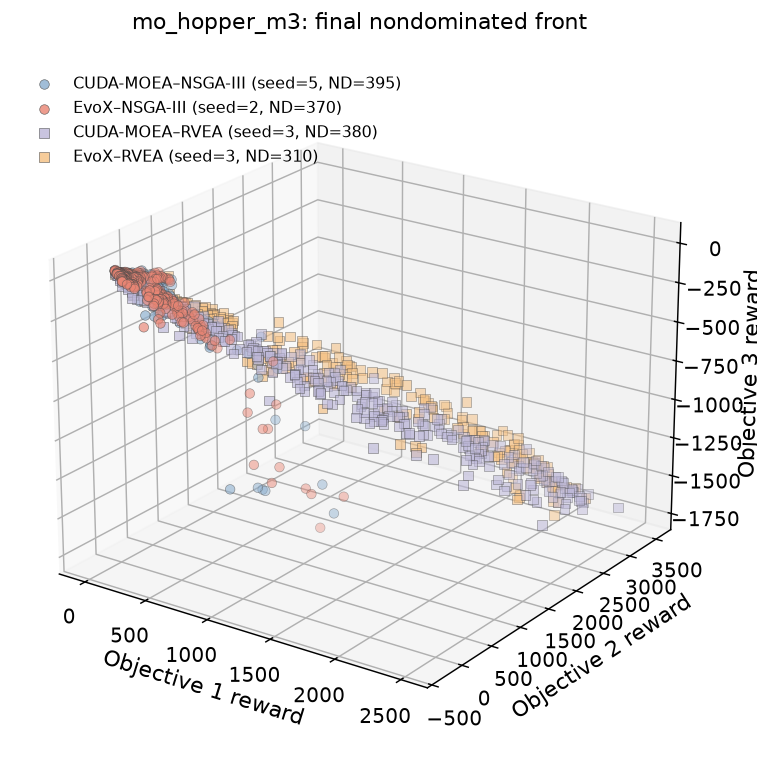

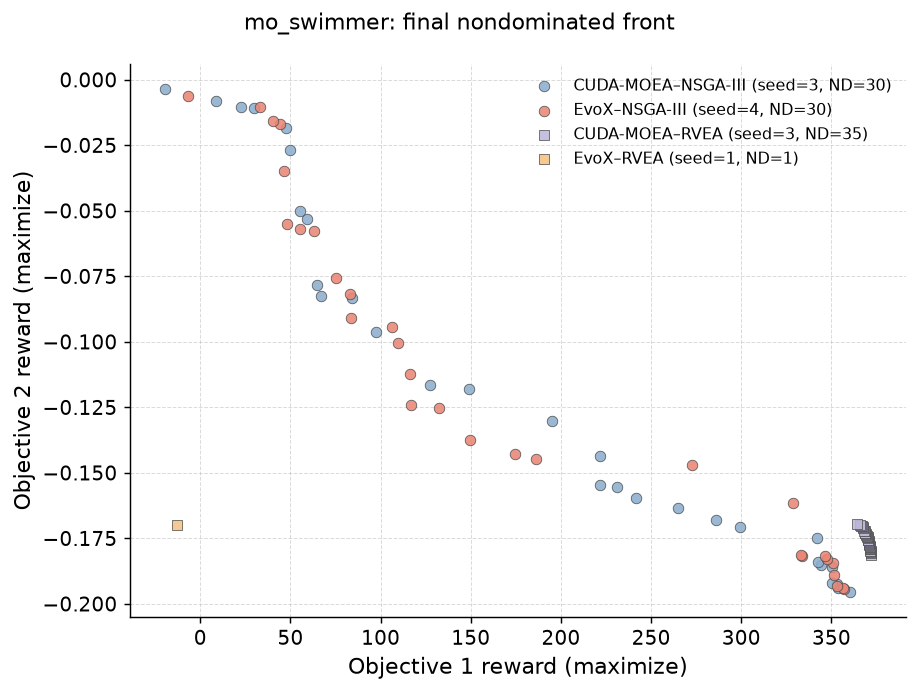

In [9]:
def plot_final_front(environment):
    records = load_run_records(runs_root, environment)
    if not records:
        print(f'跳过 {environment}: 未在 {runs_root} 找到已评估的 run_result.json')
        return

    fronts = {}
    for framework, algorithm in IMPLEMENTATION_ORDER:
        seed = representatives.get((environment, framework, algorithm))
        row = records.get((framework, algorithm, seed))
        if row is None:
            continue
        rewards = torch.load(row['checkpoint_rewards'], map_location='cpu', weights_only=True)
        generation = int(row['generations'])
        values = rewards[generation].detach().cpu().numpy().astype(float)
        fronts[(framework, algorithm)] = (seed, nondominated_front(values))

    if not fronts:
        print(f'跳过 {environment}: 没有可画的前沿')
        return
    objectives = next(iter(fronts.values()))[1].shape[1]

    if objectives == 2:
        fig, axis = plt.subplots(figsize=(7.2, 5.4))
        for key in IMPLEMENTATION_ORDER:
            if key not in fronts:
                continue
            seed, front = fronts[key]
            style = STYLES[key]
            axis.scatter(
                front[:, 0], front[:, 1], s=34, alpha=0.88,
                color=style['color'], marker=style['marker'],
                edgecolors='#4A4A4A', linewidths=0.45,
                label=f'{LABELS[key]} (seed={seed}, ND={len(front)})',
            )
        axis.set_xlabel('Objective 1 reward (maximize)')
        axis.set_ylabel('Objective 2 reward (maximize)')
        style_axes(axis)
        axis.legend(frameon=False)
    else:
        fig = plt.figure(figsize=(7.4, 6.0))
        axis = fig.add_subplot(111, projection='3d')
        for key in IMPLEMENTATION_ORDER:
            if key not in fronts:
                continue
            seed, front = fronts[key]
            style = STYLES[key]
            axis.scatter(
                front[:, 0], front[:, 1], front[:, 2], s=28, alpha=0.82,
                color=style['color'], marker=style['marker'],
                edgecolors='#4A4A4A', linewidths=0.35,
                label=f'{LABELS[key]} (seed={seed}, ND={len(front)})',
            )
        axis.set_xlabel('Objective 1 reward')
        axis.set_ylabel('Objective 2 reward')
        axis.set_zlabel('Objective 3 reward')
        axis.view_init(elev=22, azim=-55)
        axis.legend(frameon=False, loc='upper left')

    fig.suptitle(f'{environment}: final nondominated front', y=0.98, fontsize=12)
    fig.tight_layout()
    plt.show()


for environment in available_environments():
    plot_final_front(environment)